# Inhalt aus: `B200-ul-kmeans-dbscan-location.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Unsupervised Learning - KMeans & DBSCAN - Location
</b></font> </br></p>

---


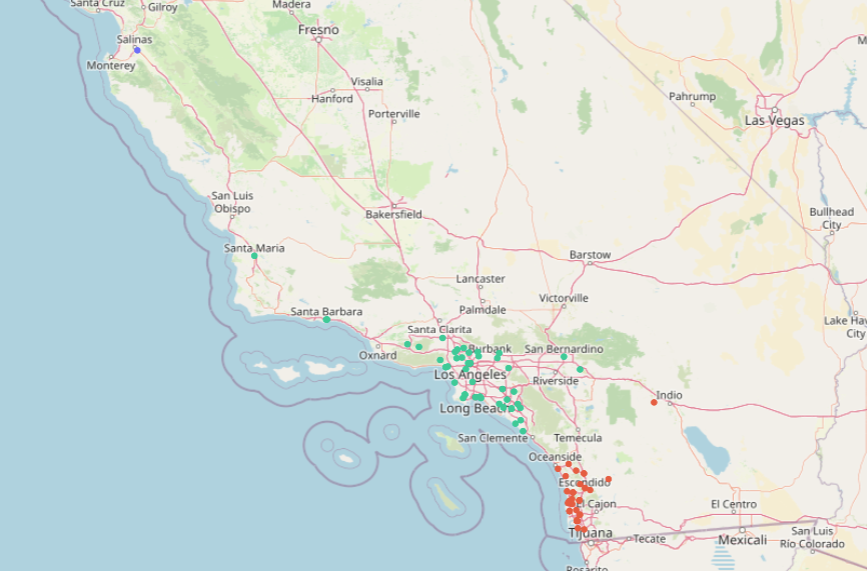

# 0  | Install & Import
***

In [ ]:
# Install

In [ ]:
# Import
from pandas import read_csv, DataFrame, concat
import numpy as np

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples

import plotly.express as px

from yellowbrick.cluster import SilhouetteVisualizer, intercluster_distance

In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# **1 |  Understand**

---


<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

<p><font color='black' size="5">
Anwendungsfall
</font></p>

Auf Basis von Geodaten kann ein Clustering erfolgen.




<p><font color='black' size="5">
Daten laden
</font></p>



In [ ]:
filename = "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/location_data.csv"
df = read_csv(filename, encoding="ISO-8859-1")

In [ ]:
data = df[df.region == "California"]
data.reset_index(inplace=True)

In [ ]:
data = data[["Lat", "Long"]]

<p><font color='black' size="5">
EDA (Exploratory Data Analysis) mit Pandas
</font></p>

In [ ]:
data.info()

In [ ]:
data.describe().T

# **2 | Prepare**

---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Duplikate ermitteln/löschen</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features Kodieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>
✅ Train-Test-Split durchführen</br>

# **3 | Modeling**
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Validiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>


<p><font color='black' size="5">
Modellauswahl & Training
</font></p>

In [ ]:
model_kmeans = KMeans(n_clusters=3)
model_kmeans.fit(data)

In [ ]:
eps = 0.5
min_samples = 5
model_dbscan = DBSCAN(eps=eps, min_samples=min_samples)
model_dbscan.fit(data)

# 4 | Evaluate
---


<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>

## 4.1 | KMeans
---

<p><font color='black' size="5">
Silhouette Coefficient KMeans
</font></p>

In [ ]:
s_score_kmeans = silhouette_score(
    data[["Lat", "Long"]], model_kmeans.labels_, metric="euclidean"
)
print(f"Silhouettenkoeffizient KMeans: {s_score_kmeans:0.2f}")

In [ ]:
silhouette_vals = silhouette_samples(data, model_kmeans.labels_)
silhouette_vals[:10]

In [ ]:
unique_clusters = np.unique(model_dbscan.labels_)
for cluster in unique_clusters:
    if cluster != -1:  # Ausreißer ignorieren
        cluster_avg_silhouette = np.mean(
            silhouette_vals[model_kmeans.labels_ == cluster]
        )
        print(
            f"Cluster {cluster}: ∅ Silhouettenkoeffizient = {cluster_avg_silhouette:.3f}"
        )

In [ ]:
visualizer = SilhouetteVisualizer(model_kmeans, colors="yellowbrick")
visualizer.fit(data)
visualizer.show()

In [ ]:
visualizer = intercluster_distance(model_kmeans, data, random_state=42)

<p><font color='black' size="5">
Centroide
</font></p>

In [ ]:
print("Centroide:")
DataFrame(model_kmeans.cluster_centers_, columns=data.columns)

## 4.2 | DBSCAN
---

<p><font color='black' size="5">
Silhouette Coefficent DBSCAN
</font></p>

In [ ]:
s_score_dbscan = silhouette_score(
    data[["Lat", "Long"]], model_dbscan.labels_, metric="euclidean"
)
print(f"Silhouettenkoeffizient DBScan: {s_score_dbscan:0.2f}")

In [ ]:
silhouette_vals = silhouette_samples(data, model_dbscan.labels_)
silhouette_vals[:10]

In [ ]:
unique_clusters = np.unique(model_dbscan.labels_)
for cluster in unique_clusters:
    if cluster != -1:  # Ausreißer ignorieren
        cluster_avg_silhouette = np.mean(
            silhouette_vals[model_dbscan.labels_ == cluster]
        )
        print(
            f"Cluster {cluster}: ∅ Silhouettenkoeffizient = {cluster_avg_silhouette:.3f}"
        )

## 4.3 | Visualiserung
---

<p><font color='black' size="5">
Aufbau Datenwürfel für Visualisierung
</font></p>

In [ ]:
data["KMeans"] = DataFrame(model_kmeans.labels_).astype("string")
data["DBSCAN"] = DataFrame(model_dbscan.labels_).astype("string")

<p><font color='black' size="5">
Visualisierung KMeans
</font></p>

In [ ]:
fig = px.scatter_mapbox(
    data, lat="Lat", lon="Long", color="KMeans", zoom=5, width=1200, height=600
)

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(title=f"KMean Clustering")
fig.show()

<p><font color='black' size="5">
Visualisierung DBScan
</font></p>

In [ ]:
fig = px.scatter_mapbox(
    data, lat="Lat", lon="Long", color="DBSCAN", zoom=5, width=1200, height=600
)

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(title=f"DBSCAN Clustering")
fig.show()

# 5 | Deploy
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>

# Inhalt aus: `B210-ul-if-nid.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Unsupervised Learning - IsolationForest - Network-Intrusion-Detektor
</b></font> </br></p>

---


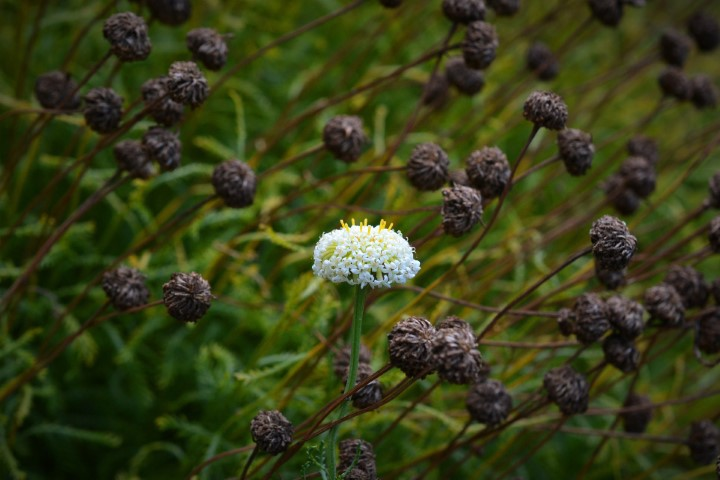

Bild von <a href="https://pixabay.com/de/users/anemone123-2637160/?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=1576948">Anemone123</a> auf <a href="https://pixabay.com/de//?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=1576948">Pixabay</a>

# 0  | Install & Import
***

In [ ]:
# Install

In [ ]:
# Import
from pandas import read_csv, DataFrame, concat

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    silhouette_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.decomposition import PCA

import plotly.express as px
import plotly.subplots as sp
import matplotlib as plt

In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings("ignore")

# 1  | Understand
***


<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

<p><font color='black' size="5">
Anwendungsfall
</font></p>

Dies ist der Datensatz, der für den Third International Knowledge Discovery and Data Mining Tools Competition verwendet wurde. Die Wettbewerbsaufgabe bestand darin, einen Netzwerk-Intrusion-Detektor zu bauen, ein Vorhersagemodell, das in der Lage ist, zwischen schlechten Verbindungen, sogenannten Intrusionen oder Angriffen, und guten normalen Verbindungen zu unterscheiden. Diese Datenbank enthält einen zu prüfenden Standarddatensatz, der eine Vielzahl von Eindringversuchen umfasst, die in einer militärischen Netzwerkumgebung simuliert wurden.

Der ursprüngliche KDD Cup 1999-Datensatz aus dem  UCI-Repositorium für maschinelles Lernen  enthält 41 Attribute (34 kontinuierlich und 7 kategorial), sie werden jedoch auf 3 Attribute (Dauer, src_bytes, dst_bytes) reduziert.

Da die kontinuierlichen Attributwerte um '0' herum konzentriert sind, haben wir jeden Wert durch y = log(x + 0,1) in einen Wert weit von '0' transformiert.

Aus KDD Cup 1999-Datensatz werden ca. 500k „http“-Dienstdaten verwendet.

Der KDD Cup ist der jährliche Data-Mining- und Knowledge-Discovery-Wettbewerb, der von der ACM Special Interest Group on Knowledge Discovery and Data Mining, der führenden Berufsorganisation von Data-Minern, organisiert wird.


[DataSet](https://www.openml.org/search?type=data&status=active&id=1113)

[Info](http://odds.cs.stonybrook.edu/http-kddcup99-dataset/)


[UCI](https://archive.ics.uci.edu/ml/datasets/kdd+cup+1999+data)

[KDD](https://kdd.org/kdd-cup)



**Datensatz:**

| feature name  | description                                      | type        |
|------------|--------------------------------------------------|-------------|
| duration   | length (number of seconds) of the connection     | continuous  |
| src_bytes  | number of data bytes from source to destination  | continuous  |
| dst_bytes  | number of data bytes from destination to source  | continuous  |

<br>
<br>


In [ ]:
df = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/kddcup1999_xs.csv"
)

In [ ]:
data = df.copy()
target = data.pop("Intrusion")

In [ ]:
target.value_counts()

# **2 | Prepare**

---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Duplikate ermitteln/löschen</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features Kodieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>
✅ Train-Test-Split durchführen</br>

# **3 | Modeling**
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Validiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

 <p><font color='black' size="5">
Modellauswahl & Training
</font></p>

In [ ]:
model = IsolationForest(
    n_estimators=250, max_samples=512, contamination=0.005, random_state=42
)

In [ ]:
model.fit(data)

# 4 | Evaluate
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>

<p><font color='black' size="5">
Prognose
</font></p>

In [ ]:
target_pred = model.predict(data)

In [ ]:
target_pred = DataFrame(target_pred)
target_pred.columns = ["Intrusion"]
target_pred.value_counts()

In [ ]:
# Der Anomaliewert der Eingabestichproben. Negative Werte sind Outlier, positive Werte Inliers.
a_value = model.decision_function(data)

<p><font color='black' size="5">
Silhouette Koeffizient
</font></p>

In [ ]:
silhouette_coef = silhouette_score(data, target_pred)
print("Silhouette-Koeffizient:", silhouette_coef)

<p><font color='black' size="5">
UmKodierung Ergebnisse Isolation Forest
</font></p>

In [ ]:
target_pred.replace([-1, 0, 1], [1, 0, 0], inplace=True)

<p><font color='black' size="5">
Confusion Matrix
</font></p>

In [ ]:
conf_matrix = confusion_matrix(target, target_pred)
plt.rcParams["figure.figsize"] = [5, 5]
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=["No", "Yes"])
disp.plot(cmap="Blues")

In [ ]:
print(classification_report(target, target_pred, target_names=["No", "Yes"]))

<p><font color='black' size="5">
Aufbau Analysewürfel
</font></p>

In [ ]:
# Übernahme der Testdaten
cube = data.copy()
cube.reset_index(inplace=True)

# Übernahme Target real & predict
cube["real"] = DataFrame(target.values)
cube["predict"] = target_pred.Intrusion
cube["a_value"] = DataFrame(a_value)

In [ ]:
# Erstellung 2D Features über Dimensionsreduktion PCA - unsupervised
pca = PCA(n_components=2)
pca = pca.fit_transform(data)
pca_df = DataFrame(pca)

# Cube um pca erweitern
cube["PCA1"] = pca_df[0]
cube["PCA2"] = pca_df[1]

<p><font color='black' size="5">
Visualisierung real vs predict
</font></p>

In [ ]:
# Histogramm
title_ = "Histogramm real vs predict"
fig = px.histogram(cube, x=["real", "predict"], nbins=2, text_auto=".2s", title=title_)
fig.update_layout(barmode="group", bargap=0.1, width=600, height=600)
fig.show()

In [ ]:
# 2 x Scatterplots

cube["real_cat"] = cube["real"].astype(str)
cube["predict_cat"] = cube["predict"].astype(str)

title_ = "Streupunktdiagramm real"
img1 = px.scatter(cube, x="PCA1", y="PCA2", color="real_cat", width=600, height=600)

title_ = "Streupunktdiagramm predict"
img2 = px.scatter(cube, x="PCA1", y="PCA2", color="predict_cat", width=600, height=600)

fig = sp.make_subplots(
    rows=1, cols=2, subplot_titles=("Scatterplot real", "Scatterplot predict")
)

for trace in img1.data:
    fig.add_trace(trace, row=1, col=1)
for trace in img2.data:
    fig.add_trace(trace, row=1, col=2)

# Layout anpassen
fig.update_layout(width=1000, height=500, title_text=title_)

# Plot anzeigen
fig.show()

In [ ]:
# real <> predict
cube[cube.real != cube.predict].describe().T

In [ ]:
cube[cube.real != cube.predict]

# 5 | Deploy
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>

# Inhalt aus: `B220-ul-dbscan-nid.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Unsupervised Learning - DBSCAN - Network-Intrusion-Detektor
</b></font> </br></p>

---


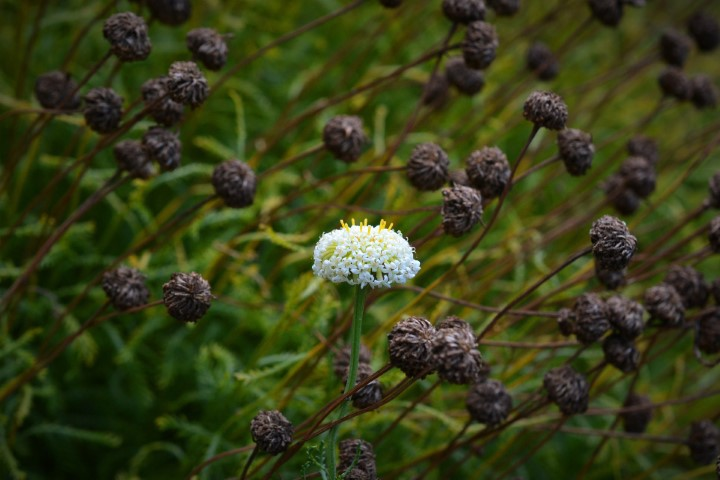

Bild von <a href="https://pixabay.com/de/users/anemone123-2637160/?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=1576948">Anemone123</a> auf <a href="https://pixabay.com/de//?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=1576948">Pixabay</a>

# 0  | Install & Import
***

In [ ]:
# Install

In [ ]:
# Import
from pandas import read_csv, DataFrame, concat

from sklearn.cluster import DBSCAN
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    silhouette_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.decomposition import PCA

import plotly.express as px
import plotly.subplots as sp
import matplotlib as plt

In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings("ignore")

# 1  | Understand
***


<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

<p><font color='black' size="5">
Anwendungsfall
</font></p>

Dies ist der Datensatz, der für den Third International Knowledge Discovery and Data Mining Tools Competition verwendet wurde. Die Wettbewerbsaufgabe bestand darin, einen Netzwerk-Intrusion-Detektor zu bauen, ein Vorhersagemodell, das in der Lage ist, zwischen schlechten Verbindungen, sogenannten Intrusionen oder Angriffen, und guten normalen Verbindungen zu unterscheiden. Diese Datenbank enthält einen zu prüfenden Standarddatensatz, der eine Vielzahl von Eindringversuchen umfasst, die in einer militärischen Netzwerkumgebung simuliert wurden.

Der ursprüngliche KDD Cup 1999-Datensatz aus dem  UCI-Repositorium für maschinelles Lernen  enthält 41 Attribute (34 kontinuierlich und 7 kategorial), sie werden jedoch auf 3 Attribute (Dauer, src_bytes, dst_bytes) reduziert.

Da die kontinuierlichen Attributwerte um '0' herum konzentriert sind, haben wir jeden Wert durch y = log(x + 0,1) in einen Wert weit von '0' transformiert.

Aus KDD Cup 1999-Datensatz werden ca. 500k „http“-Dienstdaten verwendet.

Der KDD Cup ist der jährliche Data-Mining- und Knowledge-Discovery-Wettbewerb, der von der ACM Special Interest Group on Knowledge Discovery and Data Mining, der führenden Berufsorganisation von Data-Minern, organisiert wird.


[DataSet](https://www.openml.org/search?type=data&status=active&id=1113)

[Info](http://odds.cs.stonybrook.edu/http-kddcup99-dataset/)


[UCI](https://archive.ics.uci.edu/ml/datasets/kdd+cup+1999+data)

[KDD](https://kdd.org/kdd-cup)



**Datensatz:**

| feature name  | description                                      | type        |
|------------|--------------------------------------------------|-------------|
| duration   | length (number of seconds) of the connection     | continuous  |
| src_bytes  | number of data bytes from source to destination  | continuous  |
| dst_bytes  | number of data bytes from destination to source  | continuous  |

<br>
<br>


In [ ]:
df = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/kddcup1999_xs.csv"
)

In [ ]:
data = df.copy()
target = data.pop("Intrusion")

In [ ]:
target.value_counts()

# **2 | Prepare**

---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Duplikate ermitteln/löschen</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features Kodieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>
✅ Train-Test-Split durchführen</br>

 <p><font color='black' size="5">
Train-Test-Split (nur zur Reduktion des Datenvolumens)
</font></p>

Erfolgt nur, um das Datenvolumen zu reduzieren. Bei 100k Datensätze erfolgt Abbruch mit Hinweis auf Bezahlversion. 😉

In [ ]:
data, _, target, _ = train_test_split(
    data, target, train_size=0.5, random_state=42, stratify=target
)
data.shape, target.shape

In [ ]:
target.value_counts()

# **3 | Modeling**
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Validiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

 <p><font color='black' size="5">
Modellauswahl & Training
</font></p>

In [ ]:
model = DBSCAN(eps=0.6, min_samples=30)

In [ ]:
model.fit(data)

In [ ]:
DataFrame(model.labels_).value_counts()

# 4 | Evaluate
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>

<p><font color='black' size="5">
Silhouette Koeffizient
</font></p>

In [ ]:
silhouette_coef = silhouette_score(data, model.labels_)
print("Silhouette-Koeffizient:", silhouette_coef)

<p><font color='black' size="5">
UmKodierung Ergebnisse DBSCAN
</font></p>

In [ ]:
target_pred = DataFrame(model.labels_).copy()
target_pred.columns = ["Intrusion"]
target_pred.replace([-1, 0, 1, 2], [0, 0, 0, 1], inplace=True)

In [ ]:
target_pred.value_counts()


<p><font color='black' size="5">
Confusion Matrix
</font></p>

In [ ]:
conf_matrix = confusion_matrix(target, target_pred)
plt.rcParams["figure.figsize"] = [5, 5]
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=["No", "Yes"])
disp.plot(cmap="Blues")

In [ ]:
print(classification_report(target, target_pred, target_names=["No", "Yes"]))

<p><font color='black' size="5">
Aufbau Analysewürfel
</font></p>

In [ ]:
# Übernahme der Testdaten
cube = data.copy()
cube.reset_index(inplace=True)

# Übernahem Target real & predict
cube["real"] = DataFrame(target.values)
cube["predict"] = target_pred

In [ ]:
# Erstellung 2D Features über Dimensionsreduktion PCA - unsupervised
pca = PCA(n_components=2)
pca = pca.fit_transform(data)
pca_df = DataFrame(pca)

# Cube um pca erweitern
cube["PCA1"] = pca_df[0]
cube["PCA2"] = pca_df[1]

<p><font color='black' size="5">
Visualisierung real vs predict
</font></p>

In [ ]:
# Histogramm
title_ = "Histogramm real vs predict"
fig = px.histogram(cube, x=["real", "predict"], nbins=2, text_auto=".2s", title=title_)
fig.update_layout(barmode="group", bargap=0.1, width=600, height=600)
fig.show()

In [ ]:
# 2 x Scatterplots

cube["real_cat"] = cube["real"].astype(str)
cube["predict_cat"] = cube["predict"].astype(str)

title_ = "Streupunktdiagramm real"
img1 = px.scatter(cube, x="PCA1", y="PCA2", color="real_cat", width=600, height=600)

title_ = "Streupunktdiagramm predict"
img2 = px.scatter(cube, x="PCA1", y="PCA2", color="predict_cat", width=600, height=600)

fig = sp.make_subplots(
    rows=1, cols=2, subplot_titles=("Scatterplot real", "Scatterplot predict")
)

for trace in img1.data:
    fig.add_trace(trace, row=1, col=1)
for trace in img2.data:
    fig.add_trace(trace, row=1, col=2)

# Layout anpassen
fig.update_layout(width=1000, height=500, title_text=title_)

# Plot anzeigen
fig.show()

In [ ]:
# real <> predict
cube[cube.real != cube.predict].describe().T

In [ ]:
cube[cube.real != cube.predict]

# 5 | Deploy
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>

# Inhalt aus: `B230_ul_apriori_food.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Unsupervised Learning - Apriori - Lebensmittel
</b></font> </br></p>

---


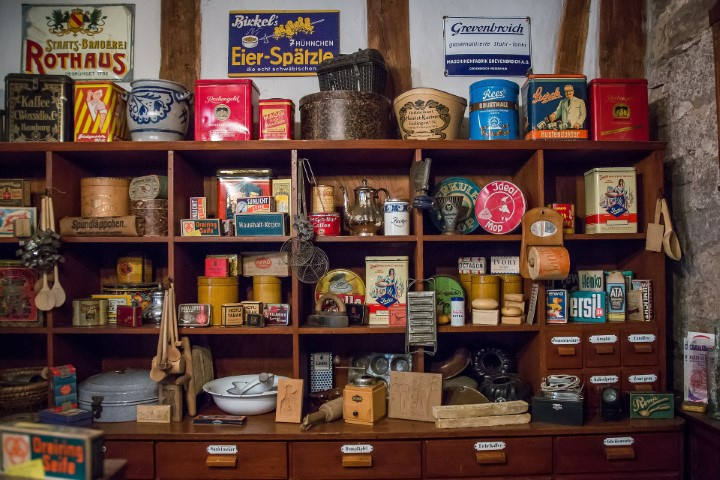

Bild von <a href="https://pixabay.com/de/users/maxmann-665103/?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=2060616">Th G</a> auf <a href="https://pixabay.com/de//?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=2060616">Pixabay</a>

[mlxtend](https://github.com/rasbt/mlxtend)

# 0  | Install & Import
***

In [ ]:
# Install

In [ ]:
# Import
from pandas import read_csv, DataFrame, concat
import numpy as np

from mlxtend.preprocessing import Transactioncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [ ]:
# Warnungen ausstellen
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", module="ipykernel.ipkernel")
warnings.filterwarnings("ignore", category=DeprecationWarning)

# **1 | Understand**
---


<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

<p><font color='black' size="5">
Daten lesen
</font></p>


In [ ]:
data = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/Basket_01_Format_1.csv",
    header=None,
)

<p><font color='black' size="5">
EDA (Exploratory Data Analysis)
</font></p>


In [ ]:
data.info()

In [ ]:
data.head(5)

In [ ]:
data.shape

# **2 | Prepare**

---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Duplikate ermitteln/löschen</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features Kodieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>
✅ Train-Test-Split durchführen</br>

<p><font color='black' size="5">
Datenaufbereitung abhängig vom Format der Quelldaten
</font></p>

+ Format 1: csv-Datei, Item1, Item2, Item3, Item4, ..
+ Format 2: csv-Datei, Transaktions-Id, Item, <weitere Datenfelder wie Datum, Shop,...>
.

In [ ]:
# @title
# @markdown <p><font size="5" color='grey'> <b> Format 1 - ✅ </b></font> </br></p>
data_new = []
for i in range(0, len(data)):  # Für alle Zeilen des DataFrames
    item_list = [str(n) for n in data.iloc[i][:] if str(n) != "nan"]
    data_new.append(list(item_list))

In [ ]:
# @title
# @markdown <p><font size="5" color='grey'> <b> Format 2 - ❌</b></font> </br></p>
# unique_transaction = data.Transaction.unique()
# data_new = []
# for index in unique_transaction:
#   rows = data[data['Transaction'] == index]
#   item_list = [n for n in rows['Item']]
#   data_new.append(list(item_list))

<p><font color='black' size="5">
Erstelle eine True/False DataFrame mit den Items als Spalte
</font></p>

In [ ]:
coder = Transactioncoder()
data_array = coder.fit(data_new).transform(data_new) # Erstellt eine Python-Liste mit True/False Angaben je Item
df = DataFrame(data_array, columns=coder.columns_)
df

# **3 | Modeling**
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Validiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

<p><font color='black' size="5">
Apriori
</font></p>

<p><font size="3">
Der Apriori-Algorithmus ist der beliebteste Algorithmus für das Mining von Assoziationsregeln. Er findet die häufigsten Kombinationen in einem Datenbestand.
<br>



# 4 | Evaluate
---


<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>

<p><font color='black' size="5">
Parameter-Set
</font></p>

In [ ]:
# Übergreifende Parameter
min_support = 0.01
min_confidence = 0.5

# Spaltenauswahl
auszug = [
    "antecedents",
    "consequents",
    "antecedent support",
    "consequent support",
    "support",
    "confidence",
    "lift",
]
auszug_num = [
    "antecedent support",
    "consequent support",
    "support",
    "confidence",
    "lift",
]
auszug_confidence = [
    "antecedents",
    "consequents",
    "antecedent support",
    "consequent support",
    "support",
    "confidence",
]
auszug_lift = ["antecedents", "consequents", "lift"]

<p><font color='black' size="5">
Berechnung
</font></p>

In [ ]:
# Berechnung Frequenzen
frequent_itemsets = apriori(df, min_support=min_support, use_colnames=True)
frequent_itemsets.support = frequent_itemsets.support.round(2) * 100  # Umrechnung in %
frequent_itemsets = frequent_itemsets[["itemsets", "support"]]  # Ändern Reihenfolge

In [ ]:
# Berechnung Regeln
associationRulesSet = association_rules(
    frequent_itemsets, num_itemsets=1, metric="confidence", min_threshold=min_confidence
)
associationRulesSet = associationRulesSet[auszug]
associationRulesSet[["confidence", "lift"]] = (
    associationRulesSet[["confidence", "lift"]] * 100
)
associationRulesSet[auszug_num] = associationRulesSet[auszug_num].round(2)

**Support**


Der Support sagt uns, wie häufig ein Item oder eine Kombination von Items  gekauft wird. Er wird als Prozentsatz aller Transaktionen angegeben.

```WENN man alle Transaktionen betrachtet, DANN ist in X% der Transaktionen Produkt A enthalten```


Beispiel:    
Wenn in 100 Einkäufen 20-mal Brot und Butter zusammen gekauft wurden, dann ist der Support für diese Kombination 20%.

In [ ]:
frequent_itemsets.head(5)

In [ ]:
frequent_itemsets.min()

In [ ]:
frequent_itemsets.max()

**Confidence**

Die Confidence zeigt, wie verlässlich eine Regel ist. Sie gibt an: Wenn Produkt A (*antecedents*) gekauft wird, wie wahrscheinlich ist es dann, dass auch Produkt B (*consequents*) gekauft wird?

```WENN Produkt A in einer Transaktion enthalten ist, DANN ist mit X% Wahrscheinlichkeit auch Produkt B in dieser Transaktion enthalten```

Beispiel:    
Wenn von 50 Kunden, die Brot kaufen, 40 auch Butter kaufen, dann ist die Confidence 80%. Die Regel "Wenn Brot, dann Butter" hat also eine hohe Verlässlichkeit.

In [ ]:
associationRulesSet[auszug_confidence].head(5)

In [ ]:
associationRulesSet[auszug_confidence].tail(5)

**Lift**

Der Lift zeigt, ob zwei Produkte ***wirklich*** zusammenhängen oder ob sie nur ***zufällig*** zusammen gekauft werden.

+ Lift = 1 → **keine** Beziehung, Produkte werden unabhängig voneinander gekauft
+ Lift > 1 → eine **positive** Beziehung/Regel, Produkte werden häufiger zusammen gekauft
+ Lift < 1 → **negative** Beziehung zwischen den Produkten, gegenseitig ausschließende oder substituierende Produkte


```WENN der Wert größer als 1 ist, DANN werden die Produkte A und B häufiger zusammen gekauft```

Beispiel:     
Ein Lift von 2,5 zwischen Brot und Butter bedeutet, dass diese Kombination 2,5-mal häufiger vorkommt als bei zufälligen Einkäufen zu erwarten wäre. Die Produkte haben also eine echte Verbindung zueinander.

In [ ]:
associationRulesSet[auszug_lift].head(5)

In [ ]:
associationRulesSet[auszug_lift].tail(5)

Confidence und Lift messen die **Stärke** einer Assoziationsregel. Die **Confidence** gibt an, wie oft die Regel stimmt, wenn die Bedingung erfüllt ist. **Lift** vergleicht diese Wahrscheinlichkeit mit der Wahrscheinlichkeit, dass die Konsequenz zufällig eintritt. Ein Lift von über 1 bedeutet, dass die Regel aussagekräftiger ist als ein zufälliges Auftreten.

# 5 | Deploy
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>

# Inhalt aus: `B240-ul-pca-special.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Principle Component Analysis - Cancer
</b></font> </br></p>

---


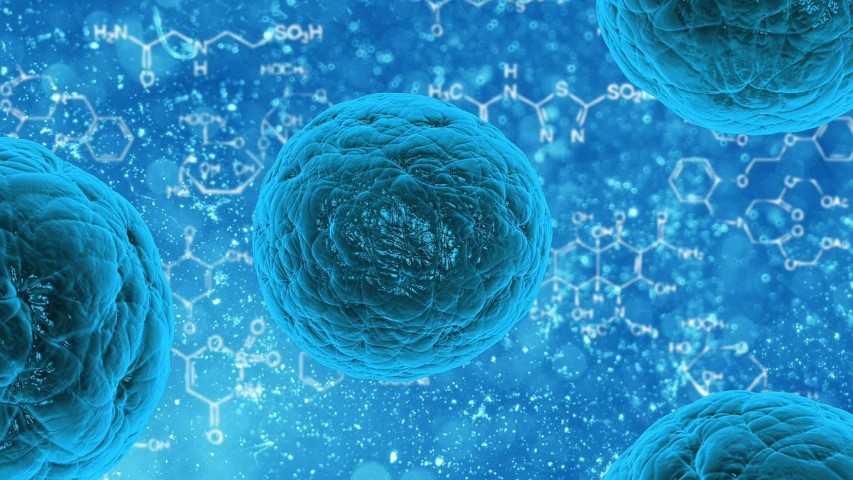

Bild von <a href="https://pixabay.com/de/users/publicdomainpictures-14/?utm_source=link-attribution&utm_medium=referral&utm_campaign=image&utm_content=163711">PublicDomainPictures</a> auf <a href="https://pixabay.com/de//?utm_source=link-attribution&utm_medium=referral&utm_campaign=image&utm_content=163711">Pixabay</a>

# **0 | Install & Import**
---

In [ ]:
# Install

In [ ]:
# Import
import numpy as np
from pandas import read_csv, DataFrame, concat

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA

import plotly.express as px

In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings("ignore")

# **1 | Understand**
---

In [ ]:
import pandas as pd
df = read_csv('https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/breast_cancer_wisconsin.csv')

In [ ]:
data = df.copy()
target = data.pop("Class")

# **2 | Prepare**
---

In [ ]:
# drop na
data = data.dropna()
target = target.loc[data.index]

# **3 | Modeling**
---

In [ ]:
n_components = data.shape[1]
model = PCA(n_components=n_components)

In [ ]:
pca_np = model.fit_transform(data)
pca_df = DataFrame(pca_np)

# 4 | Evaluate
---

<p><font color='black' size="5">
Erklärte Varianz
</font></p>

Die erklärte Varianz ist der Anteil der Gesamtvarianz im Datensatz, der durch eine bestimmte Hauptkomponente oder eine Menge von Hauptkomponenten erklärt wird. Sie ist ein Maß dafür, wie gut die Hauptkomponenten die Daten repräsentieren.

**PCA**

PCA ist eine Technik zur Dimensionsreduktion, die verwendet wird, um die Dimensionalität eines Datensatzes zu reduzieren, indem er in einen niedrigerdimensionalen Raum transformiert wird. Dies geschieht durch die Suche nach den Hauptkomponenten des Datensatzes, die die Richtungen der größten Varianz in den Daten darstellen. Die erste Hauptkomponente erklärt den größten Teil der Varianz, die zweite Hauptkomponente den zweitgrößten Teil der Varianz und so weiter.

**Erklärte Varianz in PCA**

Im Zusammenhang mit PCA wird die erklärte Varianz verwendet, um zu bestimmen, wie viele Hauptkomponenten im niedrigerdimensionalen Raum beibehalten werden sollen. Ziel ist es, so viele Hauptkomponenten beizubehalten, dass ein großer Teil der Gesamtvarianz erklärt wird, ohne zu viele Dimensionen beizubehalten.

Die erklärte Varianz jeder Hauptkomponente kann berechnet werden, indem das Eigenwert der Hauptkomponente durch die Summe der Eigenwerte aller Hauptkomponenten dividiert wird. Die Gesamtvarianz, die durch eine Menge von Hauptkomponenten erklärt wird, ist die Summe der erklärten Varianzen jeder Hauptkomponente.

**Beispiel**

Angenommen, ein Datensatz hat 10 Dimensionen und die PCA wird verwendet, um ihn auf 2 Dimensionen zu reduzieren. Die erste Hauptkomponente erklärt 70 % der Gesamtvarianz und die zweite Hauptkomponente erklärt 20 % der Gesamtvarianz. Zusammen erklären diese beiden Hauptkomponenten 90 % der Gesamtvarianz. Dies bedeutet, dass der Datensatz in einem 2-dimensionalen Raum mit einem Verlust von nur 10 % der Gesamtvarianz repräsentiert werden kann.

**Schlussfolgerung**

Die erklärte Varianz ist ein wichtiges Konzept in PCA. Sie wird verwendet, um zu bestimmen, wie viele Hauptkomponenten im niedrigerdimensionalen Raum beibehalten werden sollen. Ziel ist es, so viele Hauptkomponenten beizubehalten, dass ein großer Teil der Gesamtvarianz erklärt wird, ohne zu viele Dimensionen beizubehalten.

In [ ]:
opt_point = 90.0  # erklärte Varianz sollte >= 90% sein
explained_variance = [round(v, 3) for v in model.explained_variance_ratio_ * 100]
cum_expl_variance = np.cumsum(model.explained_variance_ratio_ * 100)
pc_greater = np.argmax(cum_expl_variance >= opt_point) + 1

In [ ]:
# Ausgabe "erklärte Varianz"
print("-" * 40)
print("Erklärte Varianz (%):\n", explained_variance)

print("-" * 40)
print("Kum. erkl. Varianz (%):\n", cum_expl_variance)

print("-" * 40)
print(f"Optimaler Punkt: {pc_greater}", "\n")

In [ ]:
# @title
# @markdown   <p><font size="4" color='green'>  Plot-Funktion</font> </br></p>
def plot_explained_variance(data, cum_sum, opt_point, d):
    # Erstelle ein DataFrame für die Daten
    df = DataFrame(
        {
            "Principal Component": range(1, data.shape[1] + 1),
            "Cumulative Explained Variance": cum_sum,
        }
    )

    # Erstelle das Liniendiagramm mit plotly-express
    fig = px.line(
        df,
        x="Principal Component",
        y="Cumulative Explained Variance",
        title="Explained Variance by Principal Components",
        labels={"Cumulative Explained Variance": "Cumulative Explained Variance"},
        width=700,
        height=400,
        markers=True,
    )

    # Füge den optimalen Punkt als Scatter hinzu
    fig.add_scatter(
        x=[d],
        y=[cum_sum[d - 1]],
        mode="markers",
        marker=dict(color="red", size=10),
        name="Opt. Point >" + str(opt_point) + "%",
    )

    # Zeige die Grafik an
    fig.show()

In [ ]:
# Grafik "erklärte Varianz"
plot_explained_variance(data, cum_expl_variance, opt_point, pc_greater)

<p><font color='black' size="5">
Gewichtung Features in den Hauptkomponenten
</font></p>

Die Werte in pca.components_ stellen die Gewichte oder Koeffizienten der ursprünglichen Features in den jeweiligen Hauptkomponenten dar.

Jede Zeile der Matrix entspricht einer Hauptkomponente.
Jede Spalte der Matrix entspricht einem ursprünglichen Feature.
Der Wert an der Position (i, j) in der Matrix gibt das Gewicht des Features j in der Hauptkomponente i an.
Interpretation:

+ Vorzeichen: Das Vorzeichen eines Gewichts (+ oder -) gibt die Richtung des Einflusses des Features auf die Hauptkomponente an. Ein positives Gewicht bedeutet, dass ein Anstieg des Feature-Werts zu einem Anstieg des Werts der Hauptkomponente führt. Ein negatives Gewicht bedeutet, dass ein Anstieg des Feature-Werts zu einem Abfall des Werts der Hauptkomponente führt.

+ Betrag: Der Betrag eines Gewichts gibt die Stärke des Einflusses des Features auf die Hauptkomponente an. Je größer der absolute Wert des Gewichts, desto stärker trägt das entsprechende Feature zur Hauptkomponente bei.

Zusammenfassend:

+ Hohe positive Werte: Das Feature trägt stark und positiv zur Hauptkomponente bei.
+ Hohe negative Werte: Das Feature trägt stark und negativ zur Hauptkomponente bei.
+ Werte nahe Null: Das Feature hat wenig Einfluss auf die Hauptkomponente.

**Beispiel:**

Nehmen wir an, wir haben einen Datensatz mit zwei Features: "Größe" und "Gewicht". Wenn die PCA eine Hauptkomponente findet, die "PCA1" genannt wird, und das Feature "Größe" einen starken und negativen Beitrag zu dieser Hauptkomponente hat, bedeutet dies, dass größere Personen tendenziell einen niedrigeren Wert auf der "PCA1"-Hauptkomponente haben.

In [ ]:
feature = data.columns
DataFrame(model.components_, columns=feature)

# 5 | Deploy
---

# Inhalt aus: `template.ipynb`
---

#  0 | Install & Import

In [ ]:
# Install


In [ ]:
# Import


In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings('ignore')

#  1 | Understand

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

#  2 | Prepare

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Duplikate ermitteln/löschen</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features Kodieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>
✅ Train-Test-Split durchführen</br>

#  3 | Modeling

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Validiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

#  4 | Evaluate

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>

#  5 | Deploy

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>